# **Focused-corpus replication: baseline vs weighted Jensen–Shannon**


## Settings & Imports

In [1]:
! git clone https://github.com/elisavetaslav/ITG-JS-persistent-homology.git
%cd ./ITG-JS-persistent-homology

Cloning into 'ITG-JS-persistent-homology'...
remote: Enumerating objects: 229, done.
remote: Counting objects: 100% (229/229), done.
remote: Compressing objects: 100% (219/219), done.
remote: Total 229 (delta 15), reused 220 (delta 9), pack-reused 0 (from 0)
Receiving objects: 100% (229/229), 440.50 KiB | 3.15 MiB/s, done.
Resolving deltas: 100% (15/15), done.
/content/ITG-JS-persistent-homology


In [2]:
!pip install -r requirements.txt

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.6/5.6 MB 27.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.0/50.0 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 842.1/842.1 kB 55.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 263.8/263.8 kB 25.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.6/48.6 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.6/54.6 kB 4.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 431.5/431.5 kB 34.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 220.9/220.9 kB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 494.3/494.3 kB 32.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.5/140.5 kB 12.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.9/223.9 kB 19.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

In [3]:
%config InlineBackend.figure_format = 'retina'

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
from persim import plot_diagrams

ROOT = Path.cwd()
sys.path.append(str(ROOT))

from visualization.plotting import setup_notebook_plots
setup_notebook_plots()

In [4]:
from parts.part_extraction import add_parts_column
from parts.duration_normalization import normalize_durations, compute_global_unit
from features.graph_construction import (
    build_expanded_graph,
    compute_original_distance_matrix,
    compute_bregman_edge_lengths
)
from features.distributions import assign_distributions
from features.persistence import compute_persistence, extract_barcode_stats
from visualization.barcodes import plot_barcodes
from features.feature_building import compute_features_for_row
from visualization.pca_dispersion import plot_pca_and_dispersion
from analysis.comparisons import compare_methods

## Datasets

The experiments in this notebook use small custom dataset of string quartet movements by Joseph Haydn, Wolfgang Amadeus Mozart, and Ludwig van Beethoven.  
The small dataset contains the focused subset corresponding to the examples listed in the original study by Mijangos et al., while the large dataset follows the broader catalogue structure used in the main experiments.  

Each work is described by a metadata table with the fields  
`filename`, `composer`, `genre`, `opus`, `key`, `movement`, and `date`.

In the present notebook, the small dataset is used for step-by-step illustration of the preprocessing pipeline.

In [ ]:
DATA_SMALL = ROOT / "data" / "raw" / "classic_music_small"
METADATA_SMALL = ROOT / "data" / "metadata" / "metadata_small.csv"

df_small = pd.read_csv(METADATA_SMALL)
print(f"Total files in the small dataset: {len(df_small)}")
df_small.sample(10)

Total files in the small dataset: 18


,filename,composer,genre,opus,key,movement,date
17,quartet12-3.mid,Beethoven,Scherzando vivace - Presto,Op.127,Eb major,3,1825
16,quartet09-3.mid,Beethoven,Menuetto: Grazioso,Op.59/3,C major,3,1805
11,k465-03.mid,Mozart,Menuetto,No.19,C major,3,1785
8,k168-03.mid,Mozart,Menuetto,No.8,F major,3,1773
2,op33n3-02.mid,Haydn,Scherzando,Op.33/3,C major,2,1781
12,k590-03.mid,Mozart,Menuetto-Allegretto,No.23,F major,3,1790
6,op77n1-03.mid,Haydn,Menuetto,Op.77/1,G major,3,1799
0,op17n2-02.mid,Haydn,Menuetto,Op.17/2,F major,2,1771
7,k158-03.mid,Mozart,Tempo di Minuetto,No.5,F major,3,1773
10,k387-02.mid,Mozart,Menuetto,No.14,G major,2,1782


## Data Extraction and Preparation

For the quartet datasets, the first four parts of each score are retained.
At this stage, every part is converted into an ordered sequence of pitch events.
For each part, the extracted representation consists of the fields `pitches`, `durations`, and `onsets`.  

Unlike the implementation in Mijangos et al., simultaneous notes are not reduced to a single upper note. Instead, chordal sonorities are linearized into ordered pitch-event sequences, so that all chord tones remain represented in the data. This preprocessing is used uniformly for both the baseline and the modified metric constructions.

This representation provides the basic musical material from which transition matrices are later constructed.

In [7]:
add_parts_column(df_small, DATA_SMALL, flat_structure=True, inplace=True)

sample = df_small['parts'][0]
print(len(sample))
print(sample[0].keys())

df_small.head()

Added 'parts' column. 18 / 18 works processed successfully.
4
dict_keys(['part_index', 'num_notes', 'pitches', 'durations', 'onsets'])


,filename,composer,genre,opus,key,movement,date,parts
0,op17n2-02.mid,Haydn,Menuetto,Op.17/2,F major,2,1771,"[{'part_index': 0, 'num_notes': 157, 'pitches'..."
1,op20n1-02.mid,Haydn,Menuetto,Op.20/1,Eb major,2,1772,"[{'part_index': 0, 'num_notes': 185, 'pitches'..."
2,op33n3-02.mid,Haydn,Scherzando,Op.33/3,C major,2,1781,"[{'part_index': 0, 'num_notes': 142, 'pitches'..."
3,op50n3-03.mid,Haydn,Menuetto,Op.50/3,Eb major,3,1787,"[{'part_index': 0, 'num_notes': 259, 'pitches'..."
4,op64n1-02.mid,Haydn,Menuetto,Op.64/1,C major,2,1790,"[{'part_index': 0, 'num_notes': 741, 'pitches'..."


## Duration normalization and transition matrix construction

The symbolic scores are encoded in quarter-length units rather than in absolute time.  
This choice removes tempo dependence and preserves the notated rhythmic structure of each piece.

To make durations comparable across the corpus, a global symbolic time unit is computed from all durations occurring in the dataset.  
More precisely, all durations are treated as rational numbers, and the smallest common unit compatible with the entire corpus is determined.  
Equivalently, this is the greatest common divisor of the rational durations, or, in implementation terms, the reciprocal of the least common multiple of their denominators.

Each duration is then rescaled by the corresponding global multiplier so that rhythmic values are expressed on a common discrete grid.  
This preserves proportional relationships within each piece while ensuring comparability across works.

An optional square-root transformation is retained in the code in order to test a perceptually motivated nonlinear weighting of durations.  
In the present experiment, however, this option is not used, so that the representation remains as close as possible to the raw symbolic rhythm.

After duration normalization, each part is converted into a weighted pitch-class transition matrix.  
Transitions are counted only between temporally adjacent events, and each transition is weighted by the product of the two corresponding durations.  
The resulting matrix is globally normalized and interpreted as a joint distribution over ordered pitch-class transitions.

In [8]:
GLOBAL_MIN_MULT = compute_global_unit(df_small)
GLOBAL_MIN_MULT

12

In [9]:
normalize_durations(df_small, GLOBAL_MIN_MULT, apply_sqrt=False, inplace=True)

**Example:** transition matrix of a single part

To illustrate the construction, the normalized transition matrix of one retained part is shown below.  
Each entry represents the relative weight of transitions from one pitch class to another within the selected part.

In [ ]:
first_row = df_small.iloc[0]
first_part = first_row['parts'][0]
P_example = first_part['transition_matrix']

print(f"Transition matrix for {first_row['composer']} - {first_row['filename']}, Part 0")
print("First 5 rows and columns:")
print(pd.DataFrame(P_example[:5, :5],
                   index=[f'from {i}' for i in range(5)],
                   columns=[f'to {j}' for j in range(5)]))

Transition matrix for Haydn - op17n2-02.mid, Part 0
First 5 rows and columns:
            to 0      to 1      to 2      to 3      to 4
from 0  0.020478  0.000000  0.025028  0.009101  0.009101
from 1  0.000000  0.000000  0.040956  0.000000  0.000000
from 2  0.009101  0.013652  0.015927  0.047782  0.009101
from 3  0.009101  0.000000  0.030717  0.013652  0.000000
from 4  0.000000  0.000000  0.010239  0.000000  0.027304


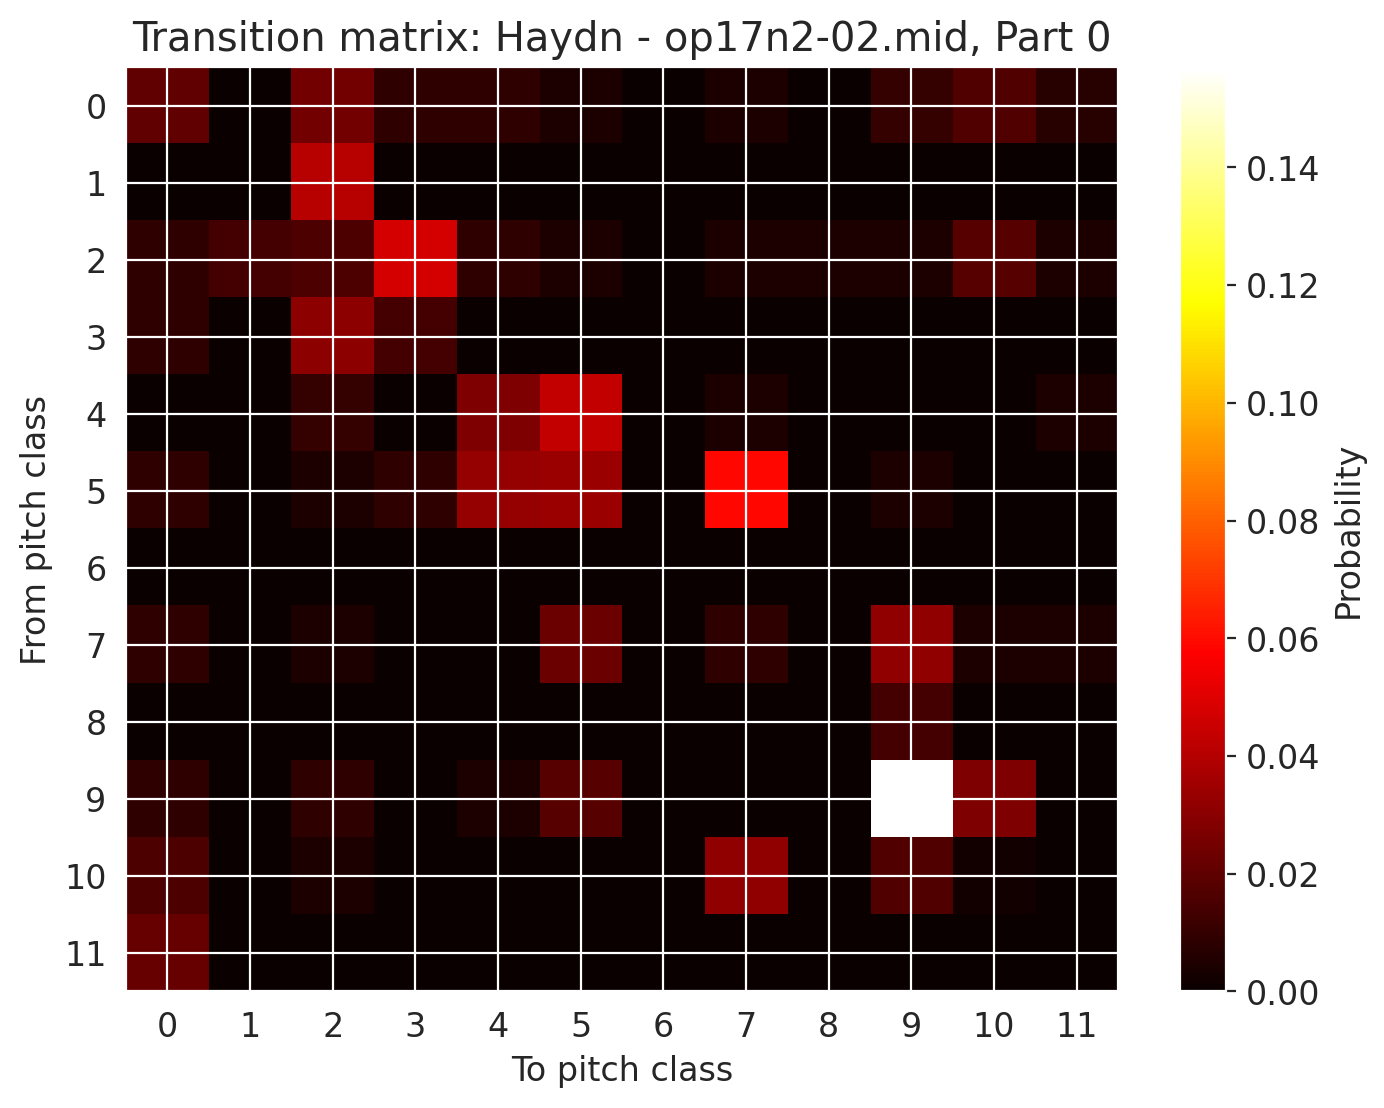

In [ ]:
plt.figure(figsize=(8, 6))
plt.imshow(P_example, cmap='hot', interpolation='nearest', aspect='auto')
plt.colorbar(label='Probability')
plt.xlabel('To pitch class')
plt.ylabel('From pitch class')
plt.title(f'Transition matrix: {first_row["composer"]} - {first_row["filename"]}, Part 0')
plt.xticks(range(12))
plt.yticks(range(12))
plt.show()

## Simple data statistics

Before passing to graph construction and topological analysis, it is useful to inspect the symbolic content of a single example.  
For the selected work, all pitch events from the retained parts are aggregated in order to visualize the empirical distribution of pitch classes and normalized durations.  
This provides a simple descriptive view of the musical material on which the subsequent transition-based construction is built.

In [ ]:
row = df_small.iloc[0]
print(f"Analyzing: {row['composer']} - {row['filename']}")

all_pitches = []
all_durations = []
for i, part in enumerate(row['parts']):
    all_pitches.extend(part['pitches'])
    all_durations.extend(part['durations'])
    print(f"part {i}: {len(part['pitches'])}")

print(f"Total notes across all parts: {len(all_pitches)}")

Analyzing: Haydn - op17n2-02.mid
part 0: 157
part 1: 118
part 2: 121
part 3: 121
Total notes across all parts: 517


In [ ]:
unique_p, counts_p = np.unique(all_pitches, return_counts=True)
print("Pitch class frequencies:")
for u, c in zip(unique_p, counts_p):
    print(f"{int(u)}: {c}")

unique_d, counts_d = np.unique(all_durations, return_counts=True)
print("\nNormalized duration frequencies:")
for u, c in zip(unique_d, counts_d):
    print(f"{u:.4f}: {c}")

Pitch class frequencies:
0: 77
1: 19
2: 63
3: 14
4: 61
5: 90
7: 58
8: 1
9: 65
10: 63
11: 6

Normalized duration frequencies:
6.0000: 86
12.0000: 309
24.0000: 63
36.0000: 59


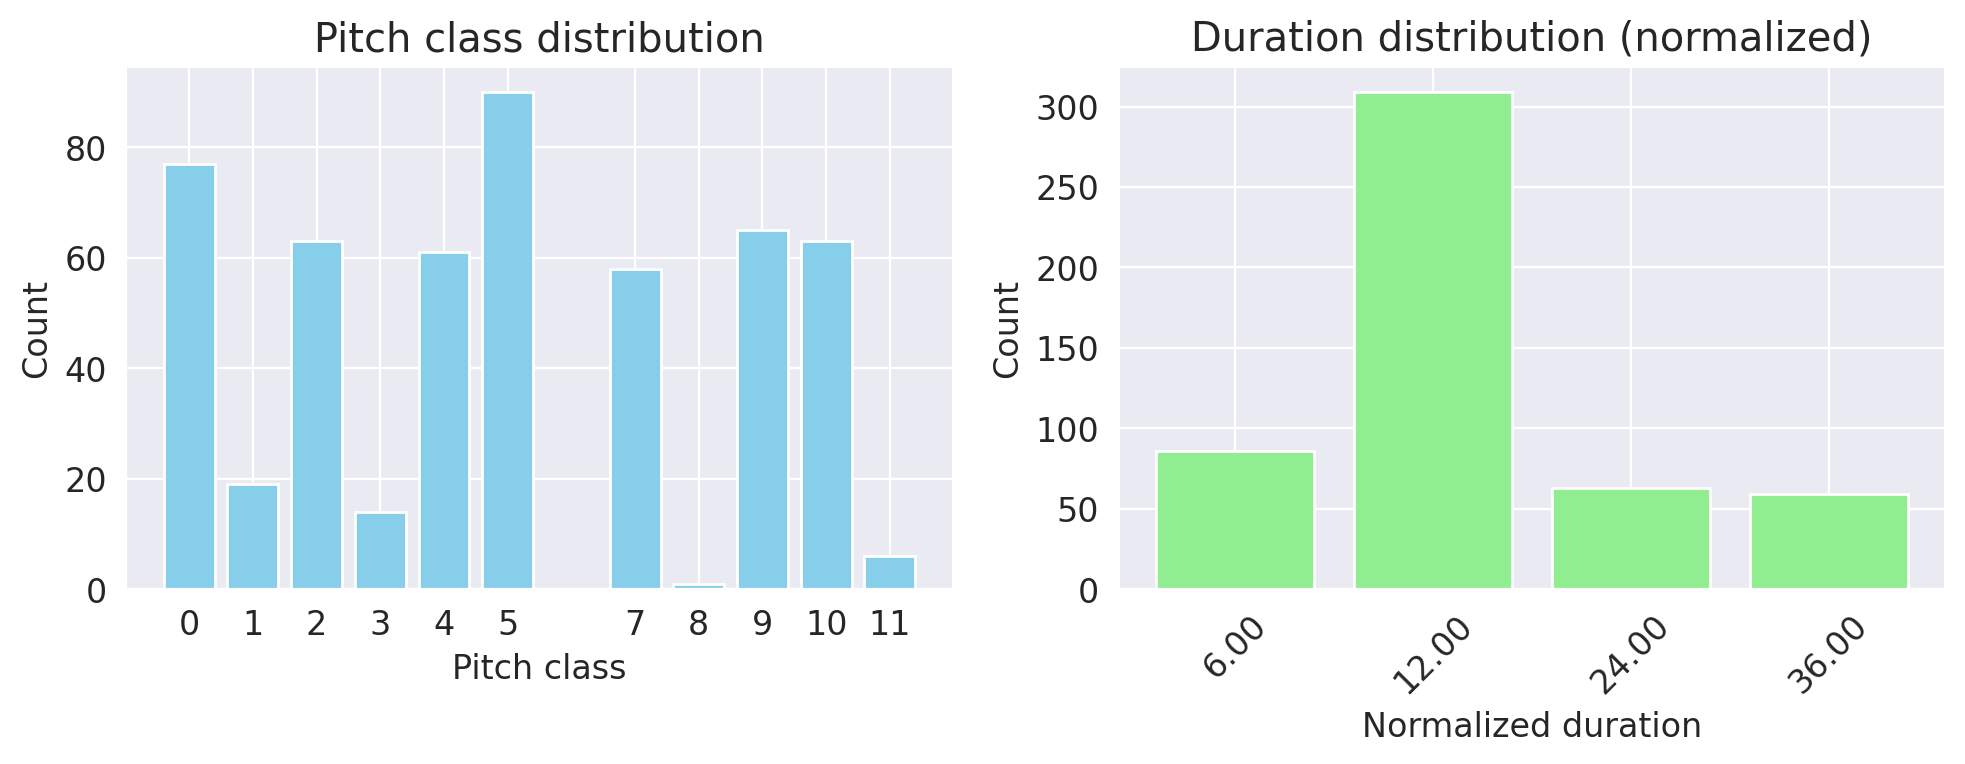

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(unique_p, counts_p, tick_label=unique_p, color='skyblue')
axes[0].set_xlabel('Pitch class')
axes[0].set_ylabel('Count')
axes[0].set_title('Pitch class distribution')

axes[1].bar(range(len(unique_d)), counts_d, tick_label=[f"{u:.2f}" for u in unique_d], color='lightgreen')
axes[1].set_xlabel('Normalized duration')
axes[1].set_ylabel('Count')
axes[1].set_title('Duration distribution (normalized)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Converting directed graph to undirected

The normalized transition matrix defines a weighted directed graph on pitch classes.  
Following the intervallic transition graph framework, each directed transition is replaced by an auxiliary vertex, which yields an expanded undirected graph.  
This reformulation makes it possible to define shortest-path dissimilarities and to pass from the transition structure to a finite matrix suitable for persistent homology.

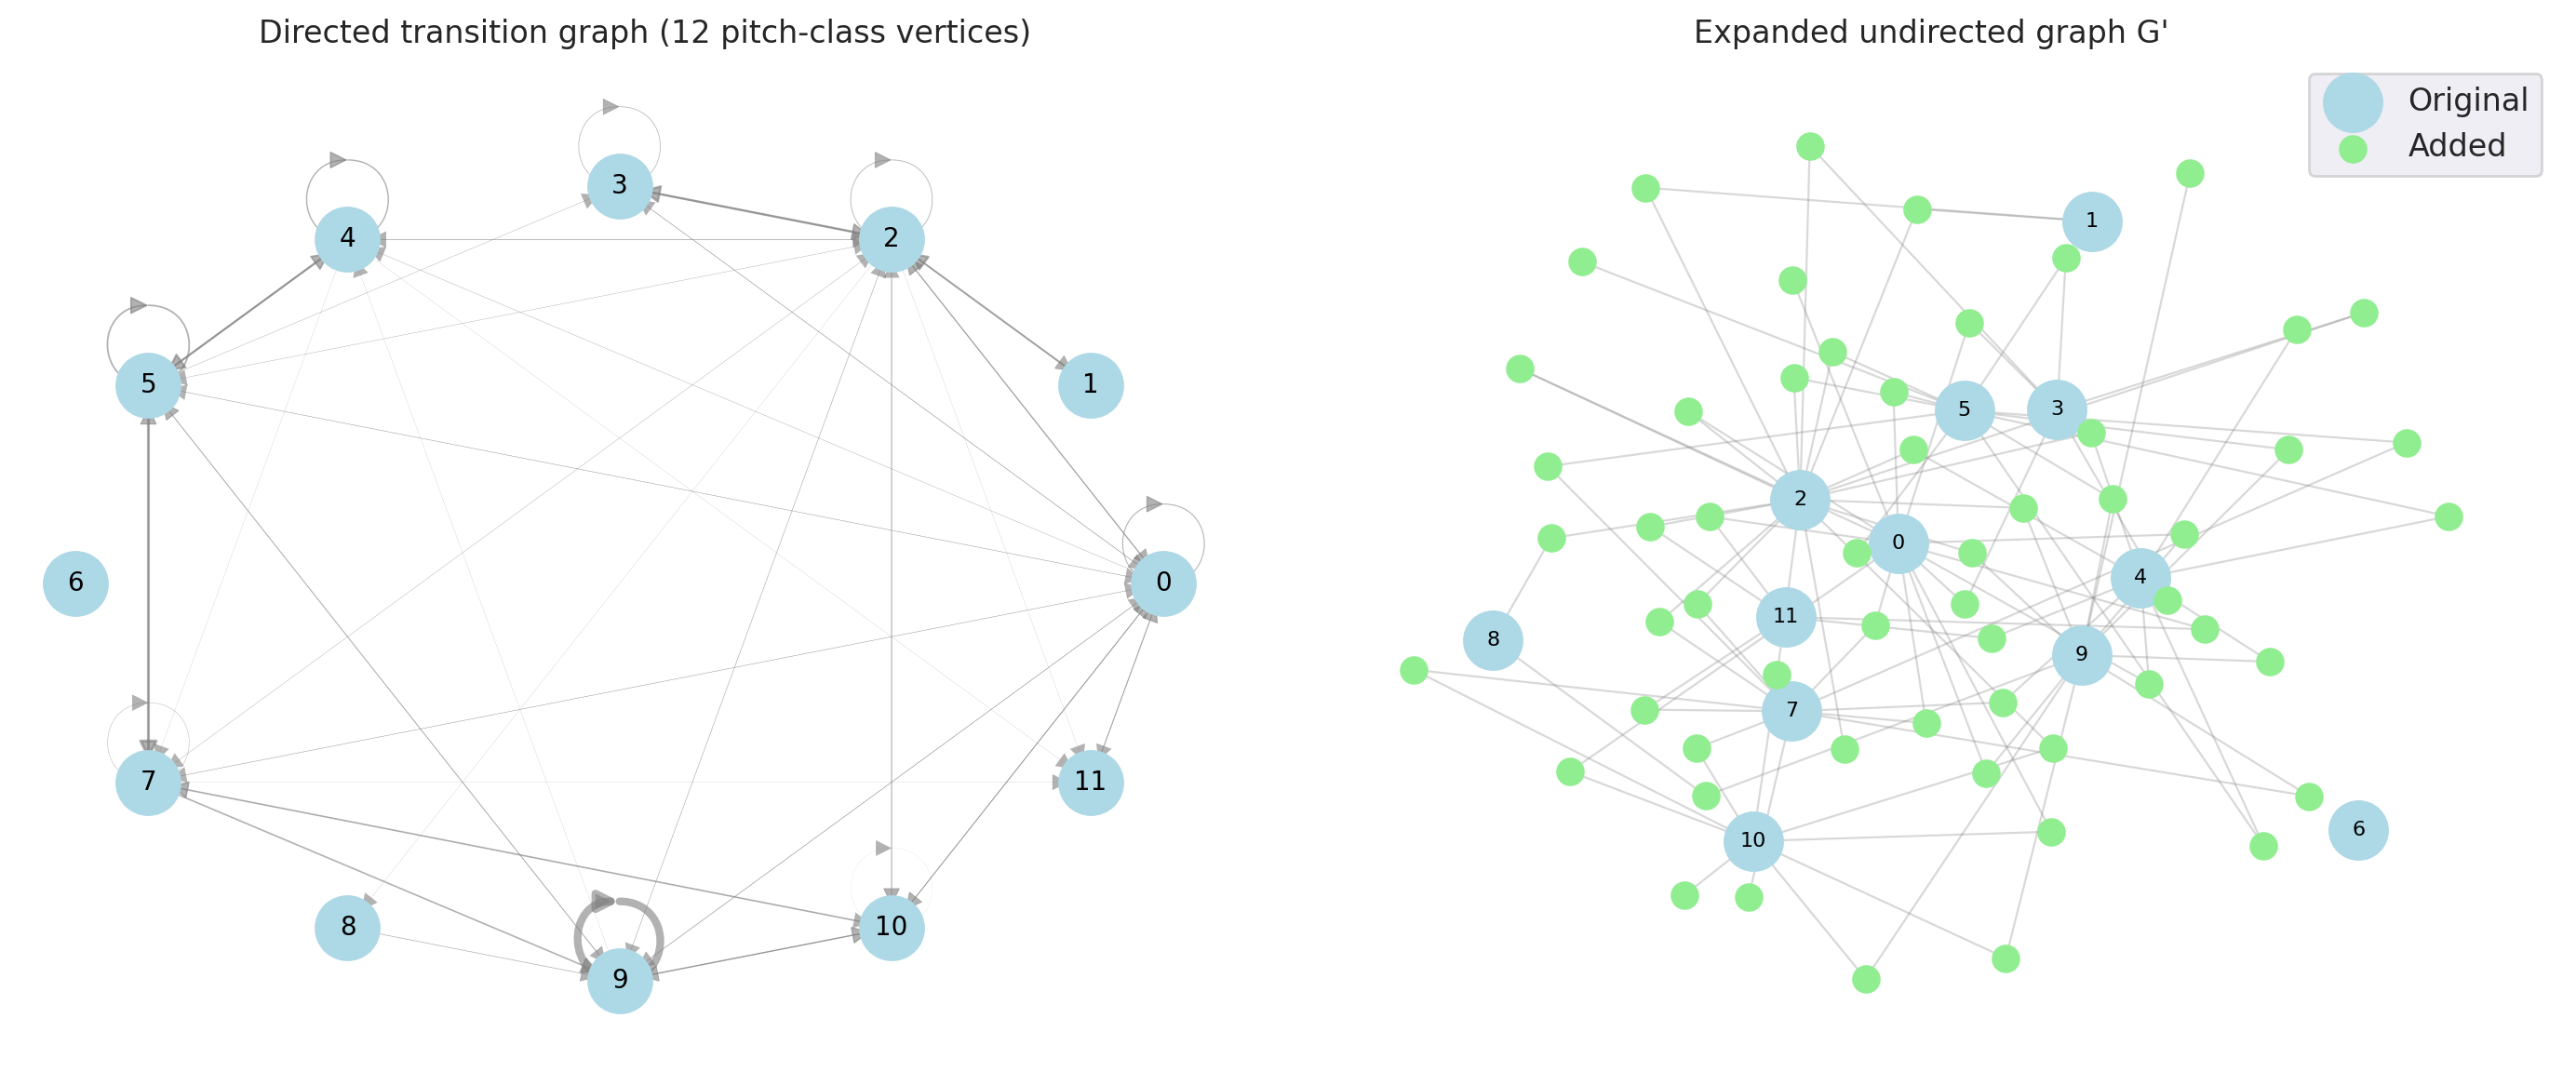

In [10]:
row = df_small.iloc[0]
P = row['parts'][0]['transition_matrix']

# -----------------------------------------
#              Directed Graph
# -----------------------------------------
G_dir = nx.DiGraph()
G_dir.add_nodes_from(range(12))
for i in range(12):
    for j in range(12):
        if P[i, j] > 0:
            G_dir.add_edge(i, j, weight=P[i, j])

plt.figure(figsize=(14, 6))
plt.subplot(1, 2, 1)
pos_dir = nx.circular_layout(G_dir)
nx.draw_networkx_nodes(G_dir, pos_dir, node_color='lightblue', node_size=600)
nx.draw_networkx_labels(G_dir, pos_dir, labels={i: str(i) for i in range(12)}, font_size=10)

edges_dir = G_dir.edges(data=True)
weights = [d['weight'] for (u, v, d) in edges_dir]
max_weight = max(weights) if weights else 1
nx.draw_networkx_edges(G_dir, pos_dir, edgelist=[(u, v) for u, v, d in edges_dir],
                       width=[3 * w / max_weight for w in weights],
                       alpha=0.6, arrowstyle='-|>', arrowsize=15, edge_color='gray')
plt.title("Directed transition graph (12 pitch-class vertices)", fontsize=12)
plt.axis('off')


# -----------------------------------------
#              Indirected Graph
# -----------------------------------------
vertices, vertex_map, edges = build_expanded_graph(P, min_weight=0.0, return_edges=True)

G_und = nx.Graph()
G_und.add_nodes_from(vertices)
G_und.add_weighted_edges_from(edges)

plt.subplot(1, 2, 2)
pos_und = nx.spring_layout(G_und, k=2, iterations=50, seed=42)

orig_nodes = list(range(12))
new_nodes = list(range(12, len(vertices)))
nx.draw_networkx_nodes(G_und, pos_und, nodelist=orig_nodes, node_color='lightblue', node_size=500, label='Original')
nx.draw_networkx_nodes(G_und, pos_und, nodelist=new_nodes, node_color='lightgreen', node_size=100, label='Added')
nx.draw_networkx_labels(G_und, pos_und, labels={i: str(i) for i in orig_nodes}, font_size=8)
edges_sample = [e for e in edges if e[0] in orig_nodes or e[1] in orig_nodes]
nx.draw_networkx_edges(G_und, pos_und, edgelist=edges_sample, alpha=0.3, width=0.8, edge_color='gray')
plt.title(f"Expanded undirected graph G'", fontsize=12)
plt.axis('off')
plt.legend()

plt.tight_layout()
plt.show()

## Compute distance matrix (for Original method)

In the baseline construction, edge lengths depend only on transition weights: frequent transitions correspond to shorter edges, while rare transitions correspond to longer ones.  
The resulting all-pairs shortest-path matrix defines a dissimilarity on the vertices of the expanded graph.

Since the expanded graph need not be connected, some shortest-path distances may be infinite.  
To obtain a finite matrix suitable for topological computation, infinite entries are replaced by a larger finite penalty derived from the largest finite distance.  
This preserves the interpretation that disconnected pairs should be treated as maximally distant while allowing persistent homology to be computed from a finite dissimilarity matrix.


In [11]:
D_original = compute_original_distance_matrix(vertices, edges)
finite_vals = D_original[np.isfinite(D_original)]
D_original[~np.isfinite(D_original)] = 1.1 * (np.max(finite_vals) if len(finite_vals) > 0 else 1.0)
print(f"Distance matrix shape: {D_original.shape}")
print("First 5x5 distances (vertices 0..4):")
df_orig = pd.DataFrame(D_original[:5, :5],
                       index=[f"v{i}" for i in range(5)],
                       columns=[f"v{i}" for i in range(5)])
print(df_orig.round(4))

Distance matrix shape: (68, 68)
First 5x5 distances (vertices 0..4):
          v0        v1       v2        v3        v4
v0    0.0000   64.3712  39.9545   60.8831  109.8750
v1   64.3712    0.0000  24.4167   45.3452  122.0833
v2   39.9545   24.4167   0.0000   20.9286   97.6667
v3   60.8831   45.3452  20.9286    0.0000  118.5952
v4  109.8750  122.0833  97.6667  118.5952    0.0000


## Assigning probability distributions to vertices

The modified metric uses not only direct transition frequencies, but also the local transition profiles of pitch classes.  
For each original pitch-class vertex, the outgoing transition probabilities are normalized row-wise to form a conditional transition distribution.  
These distributions are smoothed by a small positive constant in order to avoid zero entries and to ensure numerical stability in the subsequent Jensen–Shannon computations.

Only the original pitch-class vertices receive such distributions.  
The auxiliary vertices of the expanded graph serve only to encode directed transitions in undirected form and do not carry independent probability distributions.

In [12]:
dist_dict, mass_dict = assign_distributions(vertices, vertex_map, P, eps=1e-8)

## Weighted Jensen–Shannon distance

The modified edge-length rule is based on a weighted Jensen–Shannon distance between the conditional transition distributions of pitch classes.  
Unlike the Kullback–Leibler divergence, the Jensen–Shannon construction is symmetric and remains finite after smoothing.  
Its square root defines a genuine metric, which makes it particularly suitable for the construction of Vietoris–Rips filtrations from dissimilarity matrices.

In the present implementation, the two compared distributions are weighted by the outgoing masses of the corresponding pitch classes.  
Thus the distance reflects not only how different the transition profiles are, but also how much transition mass is associated with each profile.

In [ ]:
!head -n 22 features/distances.py

import numpy as np
from scipy.special import rel_entr


def weighted_js_distance(p, q, alpha_p, alpha_q, eps=1e-12):
    """Weighted Jensen-Shannon distance.
    INPUT: p, q: probability distributions (numpy arrays)
           alpha_p, alpha_q: nonnegative vertex masses
           eps: float – small constant for numerical stability (default 1e-12)
    OUTPUT: scalar distance
    """
    if alpha_p + alpha_q == 0:
        return 0.0
    w_p = alpha_p / (alpha_p + alpha_q)
    w_q = alpha_q / (alpha_p + alpha_q)
    m = w_p * p + w_q * q

    kl_pm = np.sum(rel_entr(p + eps, m + eps))
    kl_qm = np.sum(rel_entr(q + eps, m + eps))
    js = w_p * kl_pm + w_q * kl_qm
    return np.sqrt(np.clip(js, 0.0, None))



**Conceptual overview of the weighted Jensen–Shannon modification**

The present construction keeps the expanded transition graph framework of Mijangos et al., in which each directed transition $i \to j$ is represented by an auxiliary vertex $v_{ij}$.  
However, the edge-length assignment is modified in two conceptually important ways.

First, the direct transition $i \to j$ is represented in the expanded graph by a two-step path
$$
i \longrightarrow v_{ij} \longrightarrow j.
$$
For this reason, the cost of a direct transition should be distributed across the two half-edges rather than assigned independently to each of them in an unscaled inverse-frequency form.  
In the present implementation, the baseline inverse-weight construction is therefore normalized so that for $i \neq j$
$$
\ell(i,v_{ij})=\ell(v_{ij},j)=\frac{1}{2w},
\qquad w=P(i,j),
$$
and hence the total cost of the direct two-step path is
$$
\ell(i,v_{ij})+\ell(v_{ij},j)=\frac{1}{w}.
$$
For self-transitions, only one edge is present, so the corresponding cost remains of inverse-weight type.

Second, the modified metric does not rely only on transition rarity.  
Instead, it combines the rarity term with a weighted Jensen–Shannon distance between the conditional transition distributions of the source and target pitch classes.  
Thus, for $i \neq j$, the modified edge lengths are defined by
$$
\ell(i,v_{ij})=\ell(v_{ij},j)
=
\frac{\lambda+\beta\, d_{\mathrm{JS}}^{(w)}(Q_i,Q_j)}
{2\,(w^\alpha+\varepsilon)},
$$
where $Q_i$ and $Q_j$ are the smoothed outgoing transition distributions, $d_{\mathrm{JS}}^{(w)}$ is the weighted Jensen–Shannon distance, and $\alpha,\beta,\lambda$ control the balance between rarity and contextual dissimilarity.  
For self-transitions, the modified rule reduces to the inverse-weight-type form
$$
\ell(i,v_{ii})=\frac{\text{loop_multiplier}}{w^\alpha+\varepsilon}.
$$

In this way, the modified construction preserves the expanded-graph topology but changes the metric geometry.  
A transition becomes expensive not only when it is rare, but also when it connects pitch classes with substantially different outgoing transition profiles.  
This yields a more context-sensitive notion of musical dissimilarity while keeping the same underlying combinatorial graph structure.

In [13]:
edges_br = compute_bregman_edge_lengths(vertices, vertex_map, P, dist_dict,
    mass_dict, lam=1.0, alpha=1.0,
    beta=1.0, eps=1e-10, min_weight=1e-8, loop_multiplier=1.0
)

D_bregman = compute_original_distance_matrix(vertices, edges_br)
finite_vals = D_bregman[np.isfinite(D_bregman)]
D_bregman[~np.isfinite(D_bregman)] = 1.1 * (np.max(finite_vals) if len(finite_vals) > 0 else 1.0)

In [14]:
print(f"Distance matrix shape: {D_bregman.shape}")
print("First 5x5 distances (vertices 0..4):")
df_breg = pd.DataFrame(D_bregman[:5, :5],
                       index=[f"v{i}" for i in range(5)],
                       columns=[f"v{i}" for i in range(5)])
print(df_breg.round(4))

Distance matrix shape: (68, 68)
First 5x5 distances (vertices 0..4):
          v0        v1        v2        v3        v4
v0    0.0000   92.8140   53.9492   84.2137  173.0036
v1   92.8140    0.0000   38.8648   69.1293  196.8856
v2   53.9492   38.8648    0.0000   30.2645  158.0208
v3   84.2137   69.1293   30.2645    0.0000  188.2853
v4  173.0036  196.8856  158.0208  188.2853    0.0000


The weighted Jensen–Shannon edge rule yields a new system of edge lengths on the same expanded graph.  
Shortest-path distances are then recomputed using these modified edge lengths.  
As in the baseline case, disconnected pairs are assigned a large finite penalty in order to obtain a finite dissimilarity matrix suitable for persistent homology.

## Building Vietoris–Rips filtration

Persistent homology is computed directly from the finite dissimilarity matrix via a distance-matrix based routine.  
In other words, the Vietoris–Rips filtration is not constructed explicitly by hand in the code: it is generated implicitly from the pairwise distances.

Before this step, all infinite shortest-path values are replaced by a large finite penalty.  
This is necessary because the persistence routine expects a finite dissimilarity matrix.  
The penalty is chosen so that disconnected vertex pairs remain substantially farther apart than connected pairs, while the matrix becomes admissible for topological computation.

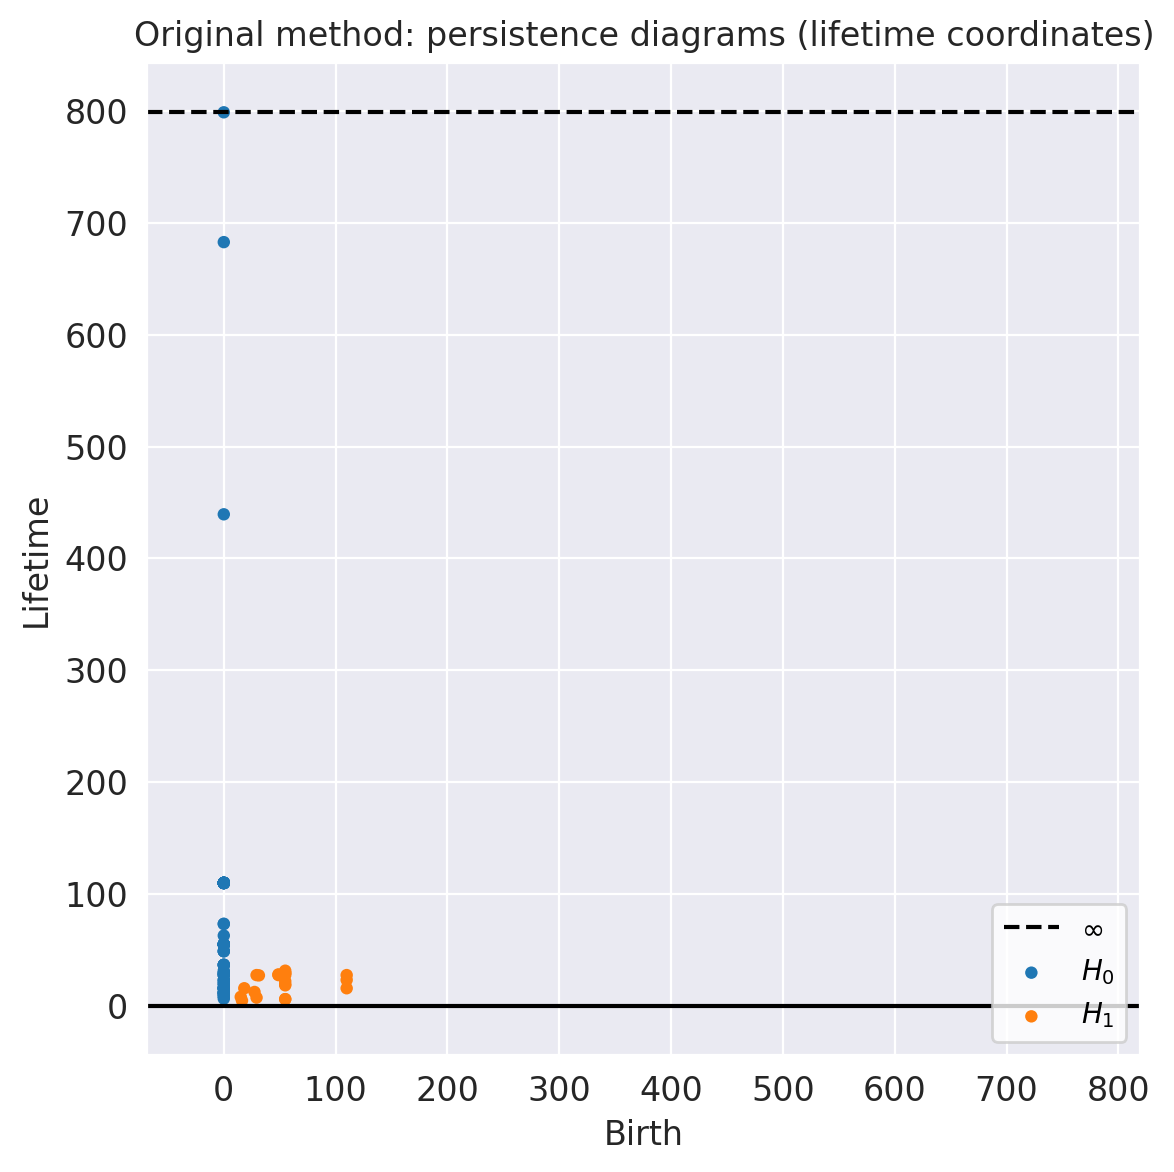

In [ ]:
# original
dgms_orig = compute_persistence(D_original)
fig, ax = plt.subplots(figsize=(10, 6))
plot_diagrams(dgms_orig, ax=ax, lifetime=True)
ax.set_title("Original method: persistence diagrams (lifetime coordinates)")
plt.tight_layout()
plt.show()

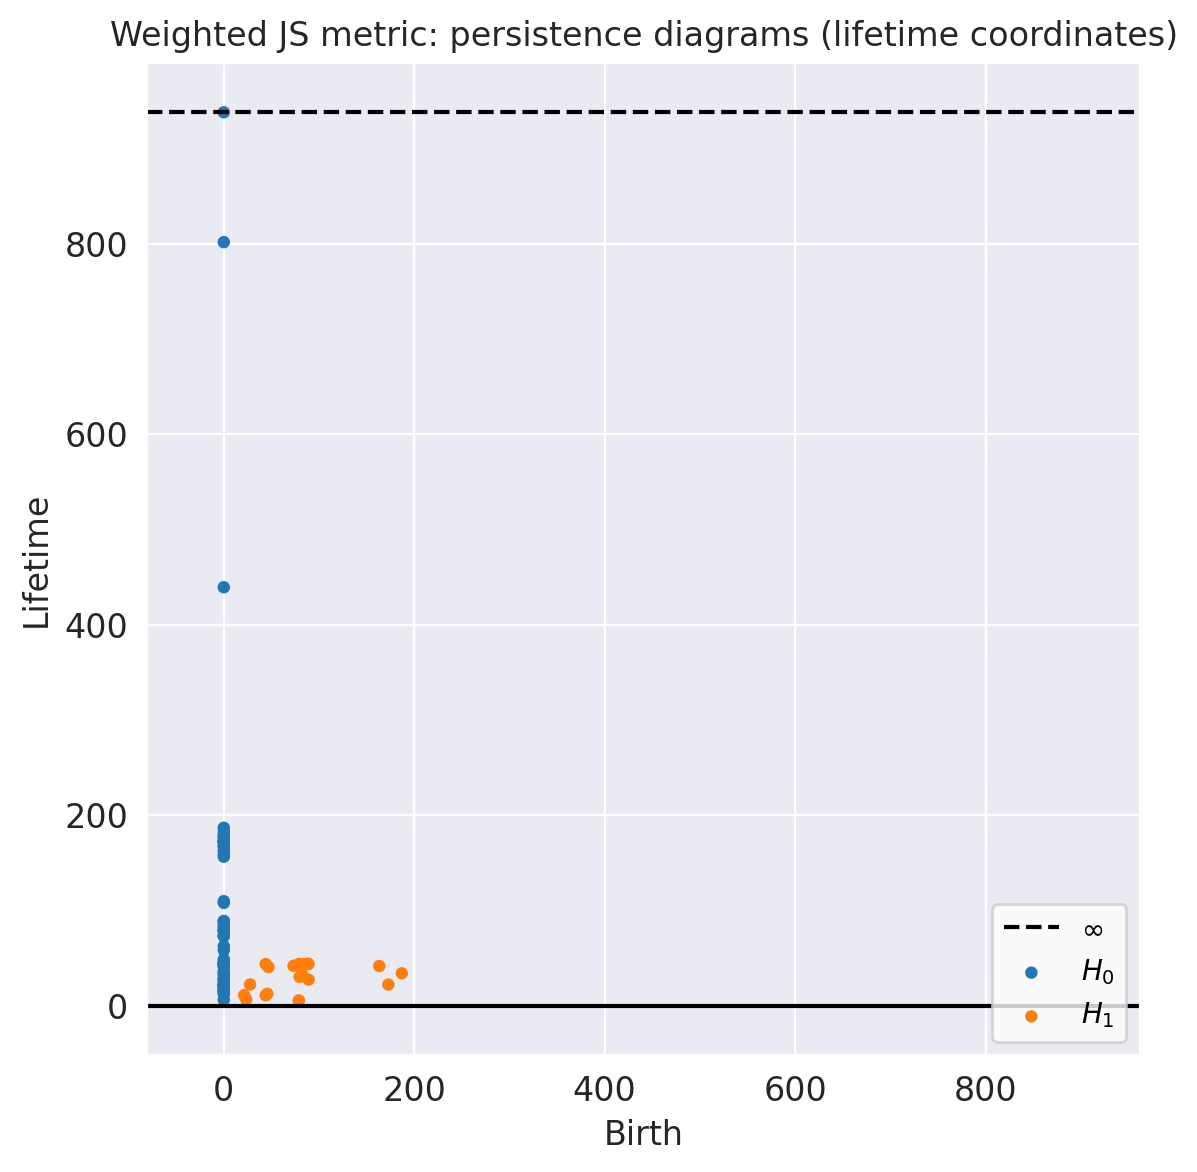

In [ ]:
# W-JS
dgms_breg = compute_persistence(D_bregman)
fig, ax = plt.subplots(figsize=(10, 6))
plot_diagrams(dgms_breg, ax=ax, lifetime=True)
ax.set_title("Weighted JS metric: persistence diagrams (lifetime coordinates)")
plt.tight_layout()
plt.show()

## Extracting summary statistics from persistence diagrams

For each homological dimension, the persistence output is summarized by three scalar descriptors: the mean lifetime, the sample standard deviation of lifetimes, and the persistence entropy.  
Finite bars contribute directly to the mean and standard deviation.  
Bars with infinite death time are treated separately: they are ignored in the mean and standard deviation, while for the entropy calculation they are assigned a surrogate finite length, following the convention used in the reference implementation.

This produces a compact numerical summary of the topological information carried by each part.

In [16]:
print("BASELINE METHOD (shortest paths)")
stats0_orig = extract_barcode_stats(dgms_orig[0])
stats1_orig = extract_barcode_stats(dgms_orig[1])
print(f"  H0: mean={stats0_orig[0]:.4f}, std={stats0_orig[1]:.4f}, ent={stats0_orig[2]:.4f}")
print(f"  H1: mean={stats1_orig[0]:.4f}, std={stats1_orig[1]:.4f}, ent={stats1_orig[2]:.4f}")

print("WEIGHTED JS METHOD")
stats0_breg = extract_barcode_stats(dgms_breg[0])
stats1_breg = extract_barcode_stats(dgms_breg[1])
print(f"  H0: mean={stats0_breg[0]:.4f}, std={stats0_breg[1]:.4f}, ent={stats0_breg[2]:.4f}")
print(f"  H1: mean={stats1_breg[0]:.4f}, std={stats1_breg[1]:.4f}, ent={stats1_breg[2]:.4f}")


BASELINE METHOD (shortest paths)
  H0: mean=68.0014, std=97.1749, ent=3.5834
  H1: mean=19.6926, std=9.1901, ent=2.9250
WEIGHTED JS METHOD
  H0: mean=94.0462, std=114.5104, ent=3.6770
  H1: mean=29.0554, std=14.9192, ent=2.8953


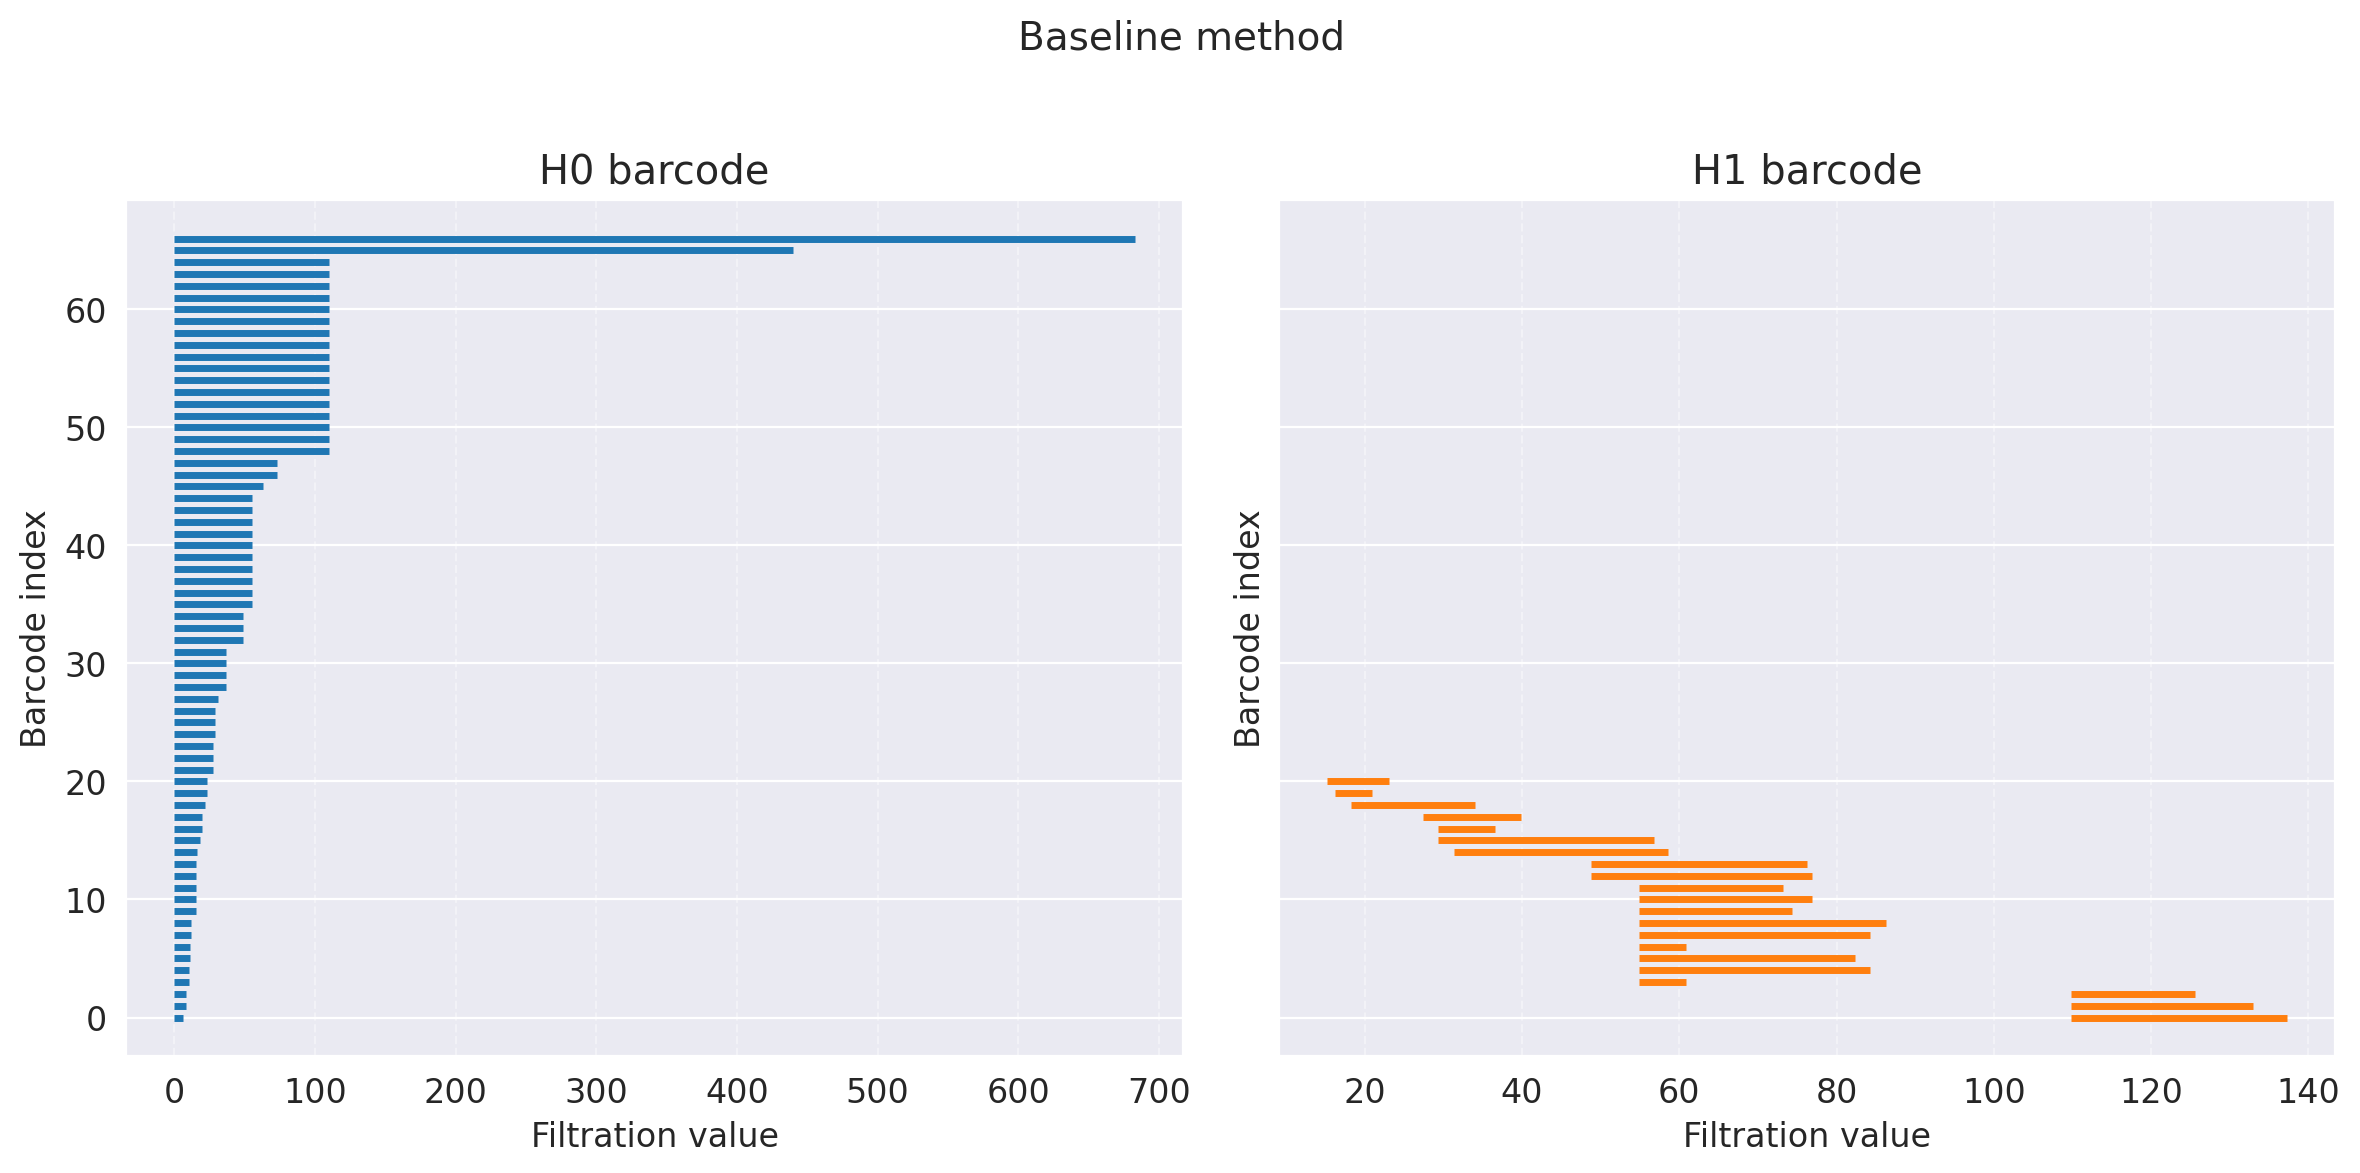

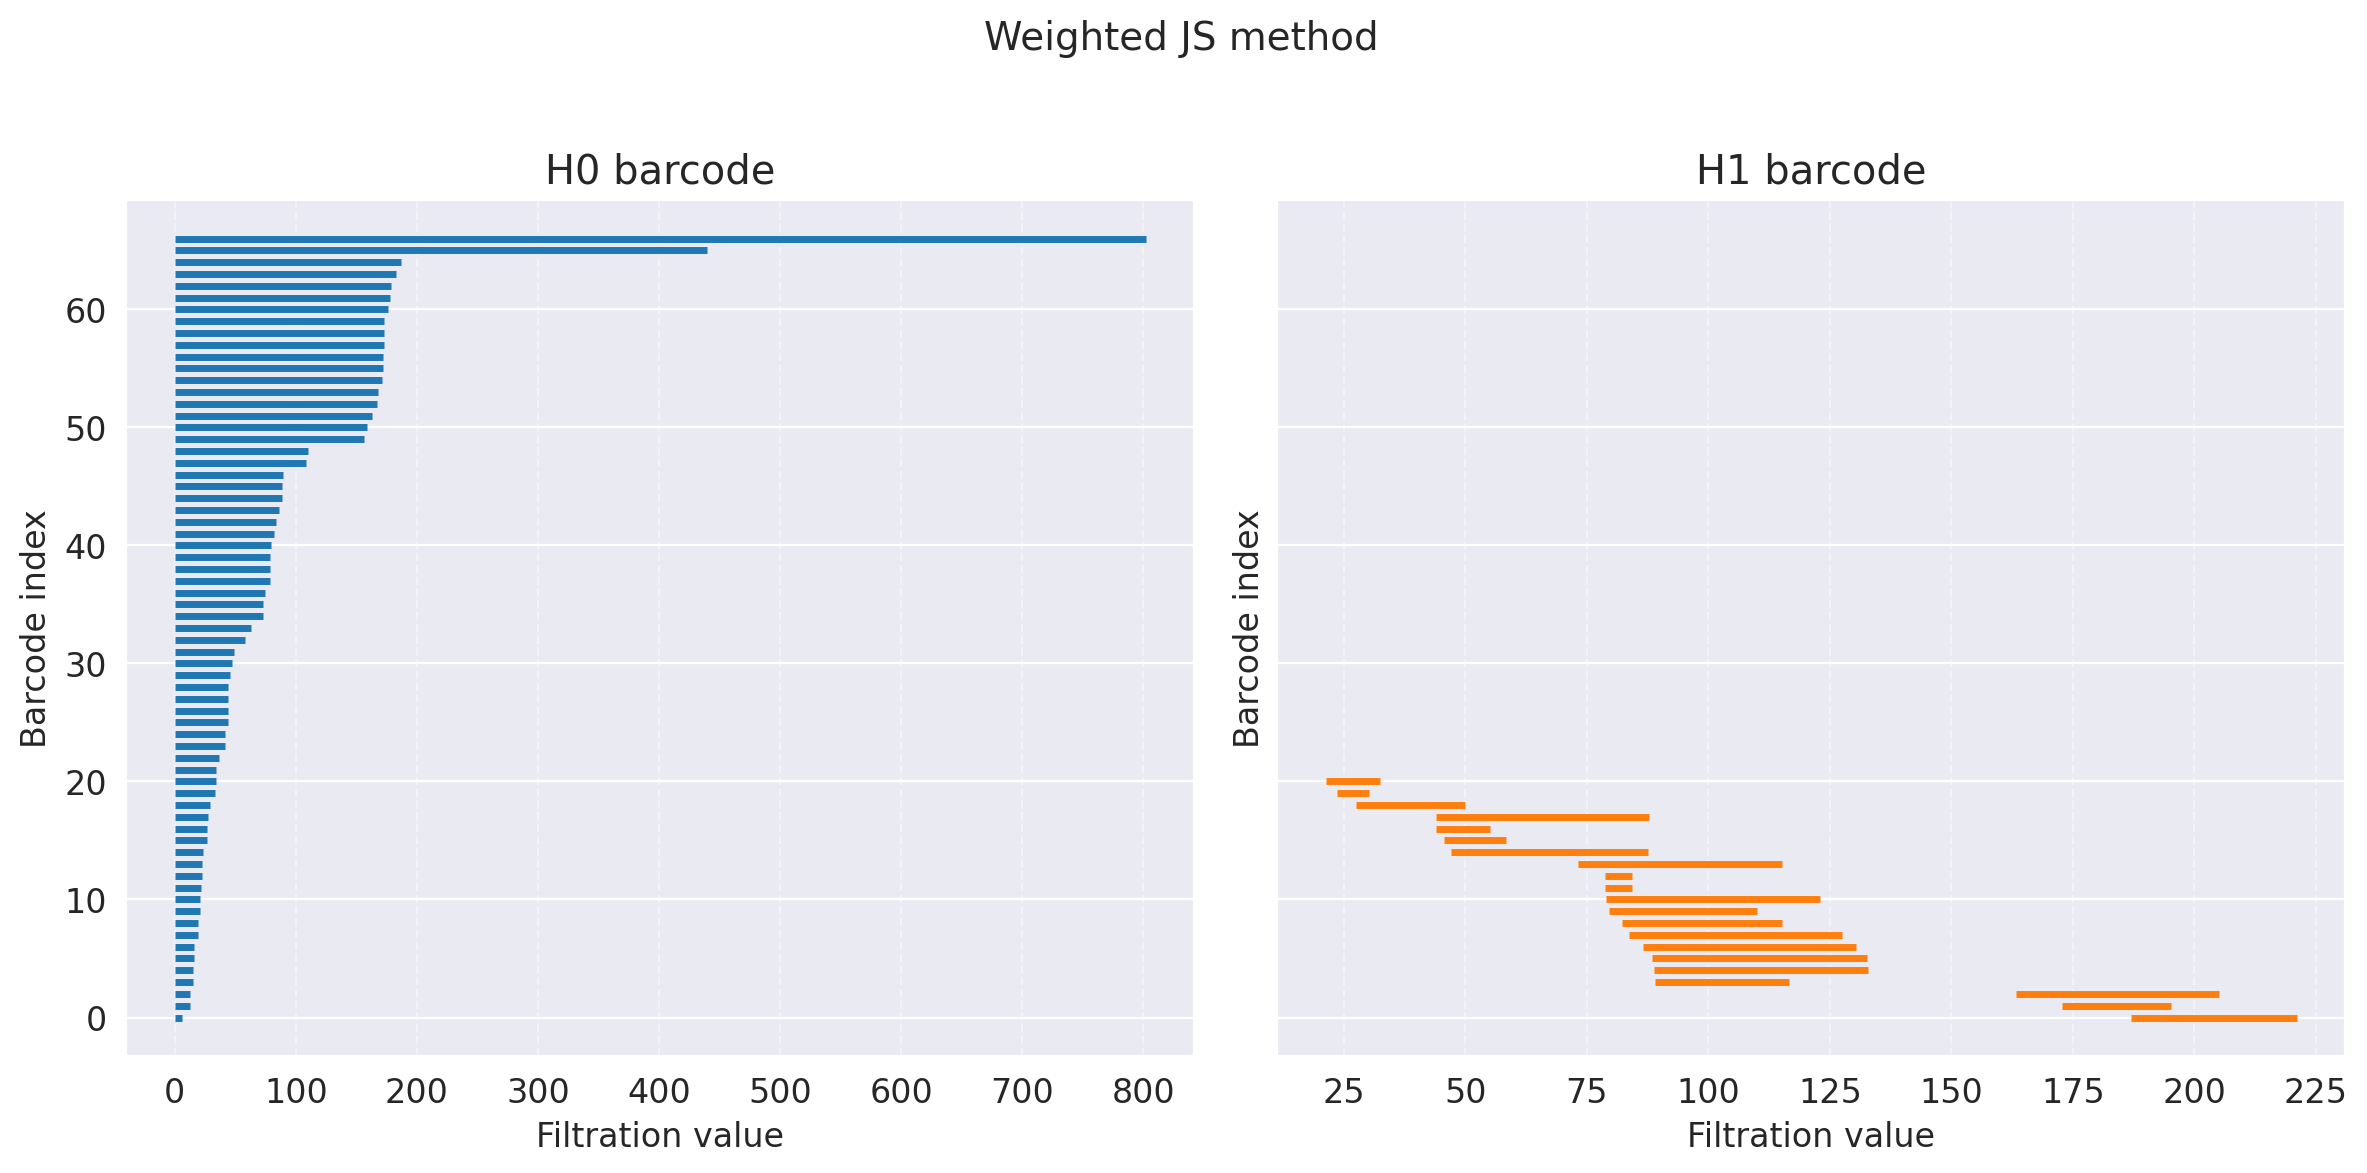

In [ ]:
plot_barcodes(dgms_orig, title="Baseline method")
plot_barcodes(dgms_breg, title="Weighted JS method")

For the illustrative single-piece example considered earlier, the weighted Jensen–Shannon metric produces persistence patterns that are systematically more extended than those of the baseline metric. In particular, the mean lifetime in $H_0$ increases from 68.00 to 94.05, while the mean lifetime in $H_1$ increases from 19.69 to 29.06. The corresponding standard deviations also grow in both dimensions, which indicates a broader spread of persistence scales under the modified metric. At the same time, the entropy values remain of comparable magnitude, suggesting that the overall distribution of barcode mass is altered, but not in a completely degenerate way.

## Formation of composition-level feature vectors

After persistent homology has been computed for each retained part, the barcode summary statistics are concatenated into a single vector.  
For each part, three statistics are extracted in dimensions $H_0$ and $H_1$, which yields six numbers per part.  
Since the quartet datasets retain four parts, each composition is represented by a 24-dimensional feature vector.

The same procedure is applied to both the baseline metric and the weighted Jensen–Shannon metric, so that the subsequent comparison reflects only the change in induced geometry.

In [17]:
df_small['features_orig'] = None
df_small['features_breg'] = None

for idx, row in df_small.iterrows():
    vec_o, vec_b = compute_features_for_row(row, alpha=1.0, beta=1.0, lam=1.0)
    if vec_o is not None:
        df_small.at[idx, 'features_orig'] = vec_o
        df_small.at[idx, 'features_breg'] = vec_b

df_valid = df_small.dropna(subset=['features_orig', 'features_breg']).copy()
print(f"Successfully processed: {len(df_valid)} из {len(df_small)}")

Successfully processed: 18 из 18


In [18]:
X_orig = np.stack(df_valid['features_orig'].values)
X_js = np.stack(df_valid['features_breg'].values)
composers = df_valid['composer'].values

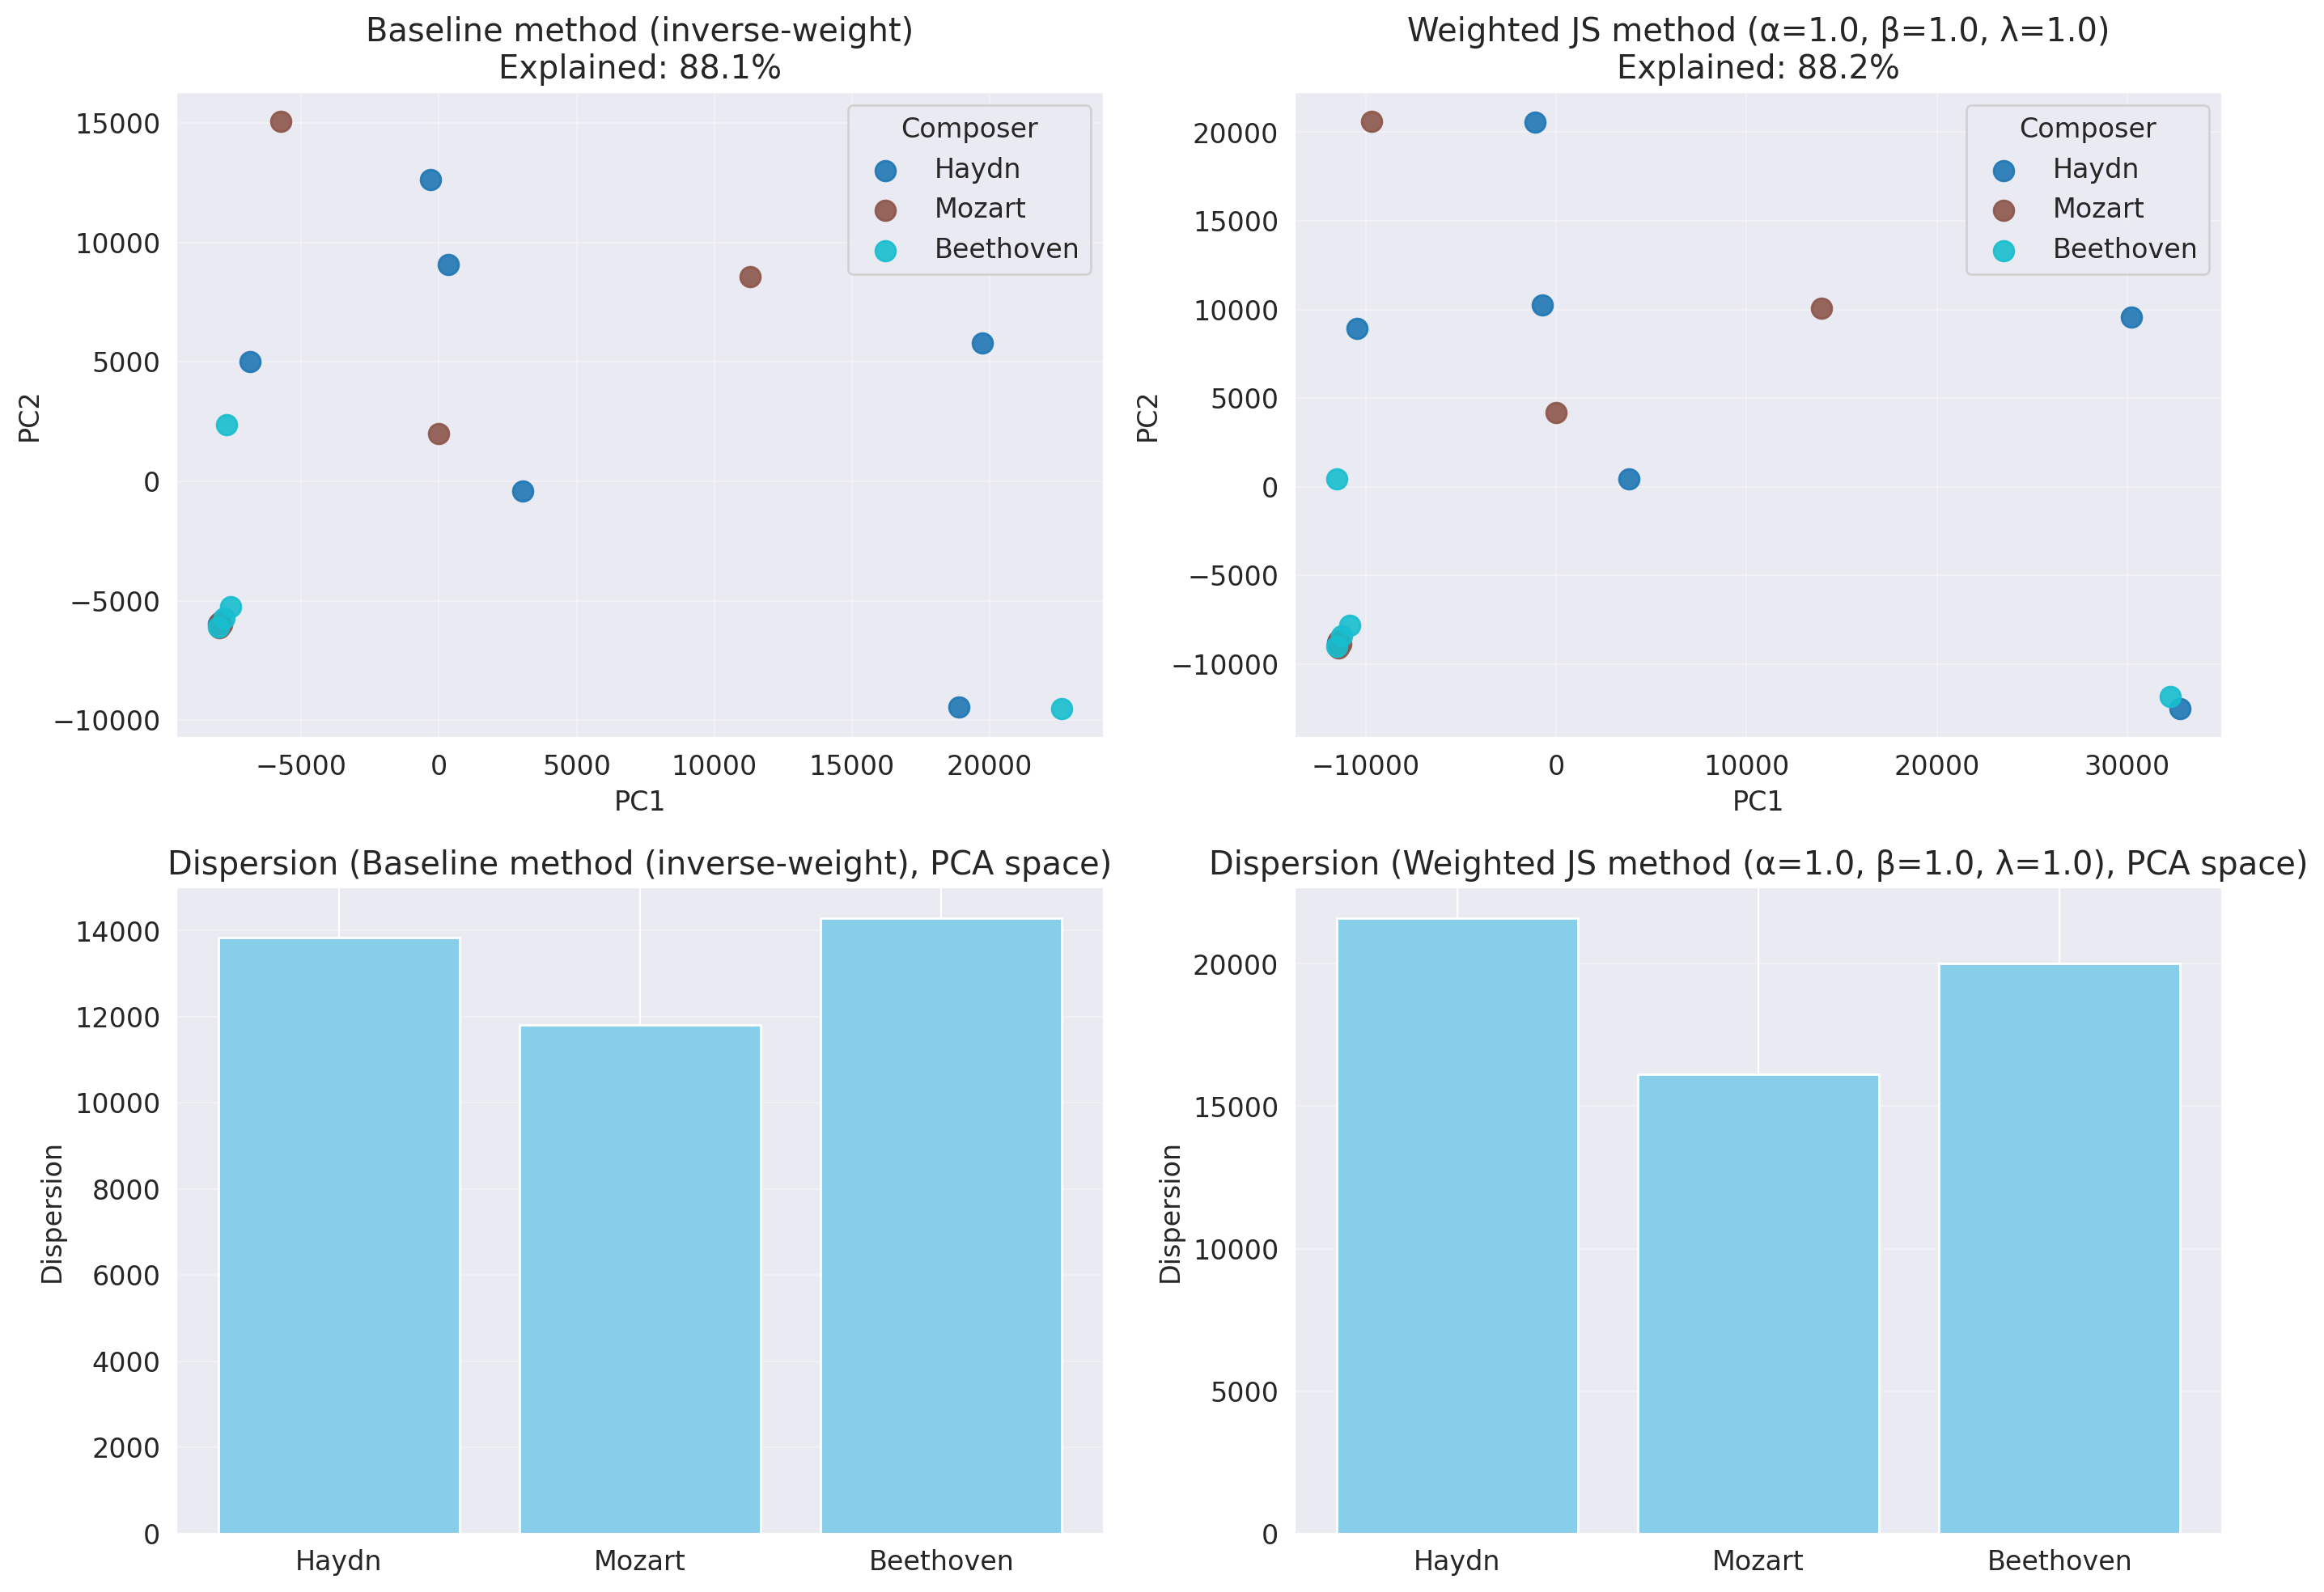

In [ ]:
fig = plt.figure(figsize=(14, 10))

ax1 = fig.add_subplot(2, 2, 1)
ax2 = fig.add_subplot(2, 2, 2)
ax3 = fig.add_subplot(2, 2, 3)
ax4 = fig.add_subplot(2, 2, 4)

plot_pca_and_dispersion(X_orig, "Baseline method (inverse-weight)", ax1, ax3, composers)
plot_pca_and_dispersion(X_js, "Weighted JS method (α=1.0, β=1.0, λ=1.0)", ax2, ax4, composers)

plt.tight_layout()
plt.show()

## Low-dimensional comparison of the two metrics

The final step of this section compares the baseline and modified feature spaces at the level of complete compositions.  
Principal Component Analysis is used for visualization, while quantitative summary measures such as silhouette score, centroid separation, and Davies–Bouldin index are reported in order to assess differences in geometric organization.

In [23]:
compare_methods(X_orig, X_js, composers)

=== Baseline ===
Explained variance (PC1+PC2): 0.881
PC1: 0.578, PC2: 0.303
Silhouette (full space): -0.0575
Silhouette (PC1+PC2): -0.1666
Davies-Bouldin: 3.3671
Intraclass variance (RMS):
  Beethoven  = 14283.4100
  Haydn      = 13844.7420
  Mozart     = 11811.4209
The average distance between the centroids (PCA space): 7444.9073

=== Weighted_JS ===
Explained variance (PC1+PC2): 0.882
PC1: 0.603, PC2: 0.279
Silhouette (full space): -0.0582
Silhouette (PC1+PC2): -0.1739
Davies-Bouldin: 3.3583
Intraclass variance (RMS):
  Beethoven  = 20008.1918
  Haydn      = 21597.2922
  Mozart     = 16113.8019
The average distance between the centroids (PCA space): 11622.8296

Metric               Baseline     Weighted_JS  Diff      
------------------------------------------------------
Explained PC1+PC2   0.8810   0.8824   +0.0014
Silhouette (full)   -0.0575   -0.0582   -0.0007
Silhouette (PCA2)   -0.1666   -0.1739   -0.0073
Davies-Bouldin      3.3671   3.3583   -0.0089


## Results

The weighted Jensen–Shannon modification changes the internal geometric organization of the focused corpus, although the effect is not uniform across all quality measures. In the baseline PCA representation, the ordering of intra-composer dispersion in the principal plane is

Mozart < Haydn < Beethoven,

whereas under the weighted Jensen–Shannon metric it becomes

Mozart < Beethoven < Haydn.

Thus Mozart remains the most compact composer class in both representations, while the most dispersed class changes from Beethoven to Haydn.

This shift is musically interpretable, but it should be read with care. The metric does not measure “absolute historical complexity” of a composer; rather, it measures the internal spread of the represented corpus in the induced feature space. In this sense, the weighted Jensen–Shannon reweighting emphasizes the internal variety of the selected Haydn sample more strongly than the baseline construction, while Beethoven becomes less extreme than in the inverse-weight model.

Quantitatively, the weighted Jensen–Shannon metric produces only a small increase in the proportion of variance captured by the first two principal components, from 0.8810 to 0.8824. The Davies–Bouldin index also improves slightly, decreasing from 3.3671 to 3.3583. At the same time, the average distance between class centroids in the PCA plane increases substantially, from 7444.9 to 11622.8, which indicates a stronger global separation of the three composer clouds in the reduced representation.

However, this improvement in global separation is accompanied by a slight deterioration in local clustering quality. The silhouette score in the full feature space changes from −0.0575 to −0.0582, and the silhouette score in the PCA plane decreases from −0.1666 to −0.1739. Thus, the weighted Jensen–Shannon metric does not improve local class coherence in the neighborhood-based sense. Its main effect is instead geometric: it stretches and redistributes the corpus in such a way that class centroids move farther apart, while the local overlap between points is not reduced.

Taken together, these results suggest that the weighted Jensen–Shannon modification does not simply sharpen clustering in a uniform way. Rather, it changes the geometry of the corpus by amplifying some large-scale stylistic differences while leaving local class interpenetration largely unresolved. This makes the modified metric interesting not as a universal optimizer of all summary indices, but as an alternative geometric model that highlights different aspects of stylistic organization.